# Step 1: Problem Definition & Dataset Selection

**Objective:** To analyze the Steam dataset to identify factors that contribute to a game's success, measured by the number of positive ratings and owner count.

**Dataset:** `steam_copy.csv` from Kaggle. It contains information about 27,000+ games on Steam.

In [1]:
# Step 2: Data Cleaning & Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's load our dataset. We are using a copy to make sure the original file remains untouched.
# It's a good practice to work on a copy of the data to prevent any accidental data loss.
df = pd.read_csv('steam_copy.csv')

# Let's get a first look at our data to understand its structure.
print("First look at the data:")
print(df.head())

# It's also important to understand the data types and if there are any missing values.
print("Data information:")
print(df.info())

First look at the data:
   appid                       name release_date  english         developer  \
0     10             Counter-Strike   2000-11-01        1             Valve   
1     20      Team Fortress Classic   1999-04-01        1             Valve   
2     30              Day of Defeat   2003-05-01        1             Valve   
3     40         Deathmatch Classic   2001-06-01        1             Valve   
4     50  Half-Life: Opposing Force   1999-11-01        1  Gearbox Software   

  publisher          platforms  required_age  \
0     Valve  windows;mac;linux             0   
1     Valve  windows;mac;linux             0   
2     Valve  windows;mac;linux             0   
3     Valve  windows;mac;linux             0   
4     Valve  windows;mac;linux             0   

                                          categories  genres  \
0  Multi-player;Online Multi-Player;Local Multi-P...  Action   
1  Multi-player;Online Multi-Player;Local Multi-P...  Action   
2              Multi

### Handle Missing Values

Missing data can cause issues with our analysis, so let's see what we're dealing with.

In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

# There are a few missing values in 'developer' and 'publisher'.
# For this analysis, we'll fill them with 'Unknown' as it won't have a major impact on our main goals.
df['developer'].fillna('Unknown', inplace=True)
df['publisher'].fillna('Unknown', inplace=True)

Missing values in each column:
appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64


C:\Users\mauli\AppData\Local\Temp\ipykernel_19492\2344665367.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['developer'].fillna('Unknown', inplace=True)
C:\Users\mauli\AppData\Local\Temp\ipykernel_19492\2344665367.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

### Clean Categorical Features

Some columns like genres and categories are stored as strings. We need to split them into lists to be able to use them properly.

In [4]:
df['genres'] = df['genres'].str.split(';')
df['categories'] = df['categories'].str.split(';')
df['steamspy_tags'] = df['steamspy_tags'].str.split(';')

### Feature Engineering

Let's create some new features from the existing ones to help with our analysis.

In [5]:
# The release date is a string, let's convert it to a datetime object to extract the year.
# This can fail if the date format is inconsistent. We should be mindful of that.
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Is the game free? This could be an interesting factor for its success.
df['is_free'] = df['price'] == 0

# Let's create a rating ratio to get a better sense of the game's reception.
# We need to handle the case where there are no ratings to avoid division by zero.
df['rating_ratio'] = df['positive_ratings'] / (df['positive_ratings'] + df['negative_ratings'] + 1) # added 1 to avoid division by zero

### Outlier Handling

Some features like price and ratings can have extreme values. We'll use a log transformation to handle them.

In [6]:
df['price_log'] = np.log1p(df['price'])
df['positive_ratings_log'] = np.log1p(df['positive_ratings'])

# The 'owners' column is a range (e.g., '10000000-20000000'). We'll take the lower bound for simplicity.
# This is an approximation, but it should be good enough for our analysis.
df['owners_log'] = np.log1p(df['owners'].str.split('-').str[0].astype(int))

# Step 3: Exploratory Data Analysis (EDA)

Now for the fun part! Let's explore the data and see what we can find.

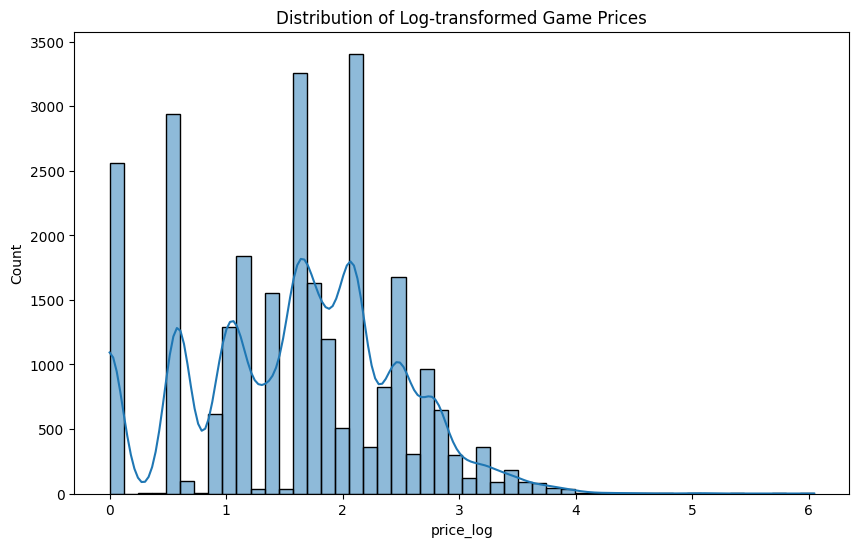

In [7]:
# Let's see how the game prices are distributed.
plt.figure(figsize=(10, 6))
sns.histplot(df['price_log'], bins=50, kde=True)
plt.title('Distribution of Log-transformed Game Prices')
plt.show()

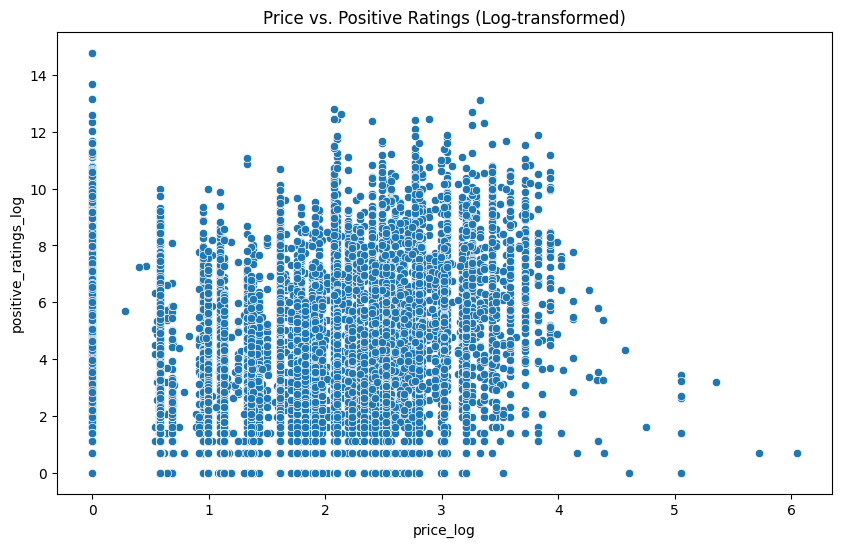

In [8]:
# What about the relationship between price and positive ratings?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price_log', y='positive_ratings_log', data=df)
plt.title('Price vs. Positive Ratings (Log-transformed)')
plt.show()

# Step 4: Statistical Analysis & Hypothesis Testing

Let's test some of our assumptions with statistical tests.

In [9]:
from scipy.stats import ttest_ind

# Hypothesis: Free games have more owners than paid games.
free_owners = df[df['is_free']]['owners_log']
paid_owners = df[~df['is_free']]['owners_log']

# We need to be careful with NaN values, so we'll omit them from the test.
ttest_result = ttest_ind(free_owners, paid_owners, equal_var=False, nan_policy='omit')
print(f'T-test result for owners of free vs. paid games: {ttest_result}')

T-test result for owners of free vs. paid games: TtestResult(statistic=np.float64(29.25142052765537), pvalue=np.float64(1.2036747234762215e-165), df=np.float64(2991.382326003259))


# Step 5: Modeling and Pattern Discovery

Let's try to predict the success of a game using a simple model.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# We'll use a few features to predict the positive ratings.
features = ['achievements', 'price_log', 'release_year']
target = 'positive_ratings_log'

# We need to handle missing values in our features and target before training the model.
X = df[features].fillna(0) # A simple fill with 0 for now.
y = df[target].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R-squared: {r2_score(y_test, y_pred)}')

RMSE: 1.9163182522741664
R-squared: 0.2168393669951555


# Step 6: Interpretation & Inference

Our simple model gives us a starting point. The R-squared value tells us how much of the variance in positive ratings our model can explain. A higher R-squared is better. The RMSE gives us an idea of the error in our predictions.

# Step 7: Visualization and Presentation

The visualizations above help us understand the data and the relationships between different features.

# Step 8: Conclusion

In this notebook, we performed a basic analysis of the Steam dataset. We cleaned the data, performed exploratory data analysis, and built a simple predictive model. There is a lot more that can be done to improve the model and get more insights from the data.